# **Experiment Notebook**



In [1]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
# <Student to fill this section>
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
import lightgbm as lgb
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK,space_eval
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
import xgboost
print(xgboost.__version__)

2.1.0


---
## A. Project Description


In [5]:
# <Student to fill this section>
student_name = "Weishu Sun"
student_id = "25721325"
group_id = "24"

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [8]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [9]:
# <Student to fill this section>
business_use_case_description = """
The goal of this project is to develop a predictive model to estimate the probability of college basketball players being drafted by the NBA.
From a business perspective, this model can help sports commentators, teams, and scouts identify promising players earlier,
allowing them to more effectively allocate scouting resources and improve the scientific and efficient nature of draft decisions.
By leveraging historical player statistics to predict draft probabilities, this reduces uncertainty in decision-making and provides data support for team management and recruiting efforts.
"""

In [10]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [11]:

# <Student to fill this section>
business_objectives = """
If the predictions are accurate, teams can better identify promising players, optimizing draft decisions and improving their competitiveness.

They can also conserve scouting resources and reduce the risk of blind scouting and misjudged investments.

Conversely, if the predictions are inaccurate, teams may miss out on promising players or select inappropriate players, wasting draft slots and funds and potentially negatively impacting the team's performance in future seasons.

Therefore, the accuracy of the model has a direct impact on team management's decision-making, capital utilization efficiency, and overall business value.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [13]:


# <Student to fill this section>
stakeholders_expectations_explanations = """
The prediction results will be used by team management, coaching staffs, and scouting teams to assist in draft decisions.
Management will use the predictions to optimize player selection strategies and enhance the team's long-term competitiveness;
Coaching staffs can use the predictions to plan tactics and lineups in advance;
Scouting teams can focus limited resources on promising players recommended by the prediction model, thereby improving scouting efficiency.

Players and their agents will also be indirectly impacted, as accurate predictions increase their chances of being noticed and selected.
Finally, team investors and fans will also be indirectly impacted, as the quality of the predictions determines the team's future performance and commercial value.
"""

In [14]:

# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [15]:

# create folder in drive

data_path ="../../data/raw"


In [16]:
# <Student to fill this section>
# Export various data from the drive and check its size
train = pd.read_csv(os.path.join(data_path, "train.csv"), encoding="latin1")
test = pd.read_csv(os.path.join(data_path, "test.csv"), encoding="latin1")
meta = pd.read_csv(os.path.join(data_path, "metadata.csv"), encoding="latin1")
sample = pd.read_csv(os.path.join(data_path, "sample_submission.csv"), encoding="latin1")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Meta shape:", meta.shape)
print("Sample_submission shape:", sample.shape)

Train shape: (14774, 62)
Test shape: (1297, 61)
Meta shape: (62, 3)
Sample_submission shape: (1297, 2)


### C.2 Define Target variable

In [17]:
# <Student to fill this section>
target_column = "drafted"

X_train = train.drop(columns=[target_column])
y_train = train[target_column]
print(X_train.shape)
print(y_train.shape)

(14774, 61)
(14774,)


In [18]:
# <Student to fill this section>
target_definition_explanations = """
In this NBA draft prediction task, the target variable is the "drafted" column in the train.csv file.
This variable is a binary label:
- drafted = 1 indicates that the player was selected by an NBA team;
- drafted = 0 indicates that the player was not selected.

The reason for choosing "drafted" as the target variable is that the business objective of this project is to predict the probability of a player being selected,
thus helping coaches, scouts, and analysts better assess a player's potential.

Therefore, "drafted," as a direct indicator of whether or not a player has been selected, is highly consistent with this prediction objective.

It is important to note that in the game submission, although the target variable is binary (0 or 1),
the model output is the probability of a player being selected (a continuous value between 0 and 1),
so that the model's discriminatory ability can be measured using the AUC-ROC metric.
"""

In [19]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [20]:
# <Student to fill this section>

target_name = "drafted"

### C.4 Explore Target variable

In [21]:
# <Student to fill this section>
target_counts = y_train.value_counts(normalize=False)
target_ratio = y_train.value_counts(normalize=True)

print("Drafted counts:\n", target_counts)
print("\nDrafted ratio:\n", target_ratio)

Drafted counts:
 drafted
0.0    14656
1.0      118
Name: count, dtype: int64

Drafted ratio:
 drafted
0.0    0.992013
1.0    0.007987
Name: proportion, dtype: float64


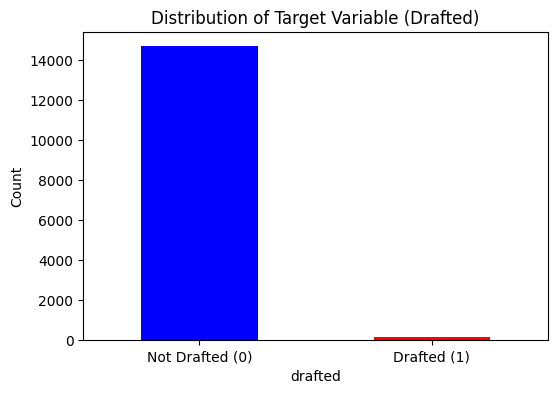

In [22]:
plt.figure(figsize=(6,4))
target_counts.plot(kind="bar", color=["blue", "red"])
plt.xticks([0,1], ["Not Drafted (0)", "Drafted (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Distribution of Target Variable (Drafted)")
plt.show()

In [23]:
# <Student to fill this section>
target_distribution_explanations = """
The distribution of the target variable drafted is extremely imbalanced: among 14,774 samples, 14,656 players were not drafted ≈99.2%,
while only 118 were drafted ≈0.8%. This extreme imbalance indicates that most players will not enter the NBA,
with only a small proportion actually being drafted.

This situation poses challenges for model training. If accuracy is used directly as an evaluation metric,
a model consistently predicting “not drafted” could achieve approximately 99% accuracy, yet completely lose the ability to identify
players with potential to be drafted. Therefore, more appropriate evaluation metrics like AUC-ROC must be employed, and category imbalance must be addressed during training.

"""

In [24]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `\<overallreview\>`

In [25]:
# <Student to fill this section>
feature_summary = train.drop(columns=['drafted']).describe().T
feature_summary['missing_ratio'] = train.drop(columns=['drafted']).isnull().mean()
print("Feature Summary:")
print(feature_summary)

Feature Summary:
                       count         mean        std          min  \
GP                   14774.0    21.251726  10.517642     1.000000   
Min_per              14774.0    25.870123  23.639878     0.000000   
Ortg                 14774.0    85.771707  34.164203     0.000000   
usg                  14774.0    17.256674   6.332899     0.000000   
eFG                  14774.0    41.507628  20.610900     0.000000   
TS_per               14774.0    44.566821  19.622173     0.000000   
ORB_per              14774.0     5.644010  15.097867     0.000000   
DRB_per              14774.0    11.992744  15.348129     0.000000   
AST_per              14774.0     9.776100   9.906416     0.000000   
TO_per               14774.0    21.493326  13.979387     0.000000   
FTM                  14774.0    20.152092  26.550462     0.000000   
FTA                  14774.0    30.266482  37.293688     0.000000   
FT_per               14774.0     0.523931   0.289864     0.000000   
twoPM            

In [26]:

#check correlation of numeric feature
numeric_features = train.select_dtypes(include=['int64', 'float64'])

correlations = numeric_features.corr()['drafted'].sort_values(ascending=False)

print("correlation：")
print(correlations.head(15))
print(correlations.tail(15))

correlation：
drafted                1.000000
dunksmade              0.373588
dunksmiss_dunksmade    0.369440
porpag                 0.295714
twoPM                  0.288880
rimmade                0.283524
dporpag                0.274490
FTA                    0.268576
FTM                    0.266280
twoPA                  0.265094
midmade                0.256524
midmade_midmiss        0.254101
rimmade_rimmiss        0.253654
Rec_Rank               0.236017
pts                    0.231489
Name: drafted, dtype: float64
TP_per         0.041170
mid_ratio      0.031974
AST_per        0.031236
dunks_ratio    0.031174
DRB_per        0.026981
year           0.026408
blk_per        0.023812
ast_tov        0.020385
ORB_per        0.013267
ftr            0.011873
stl_per        0.011554
pfr           -0.013831
TO_per        -0.027493
drtg          -0.053877
adrtg         -0.081407
Name: drafted, dtype: float64


In [27]:

# <Student to fill this section>
feature_1_insights = """
In the overall feature exploration, the dataset contains a wide range of player performance indicators,
including both numeric statistics (e.g., points, rebounds, assists, shooting attempts, efficiency ratios)
and categorical attributes (e.g., team, conference, player_id).

From the numeric features:
- Many features (such as dunksmade, twoPM, rimmade, midmade) are highly sparse and right-skewed, with a large
  proportion of zero values, which suggests the need for transformation (e.g., log-scaling, binning, or
  binary indicators for whether the player ever recorded the stat).
- Several features are strongly correlated with the target variable “drafted,” including dunksmade, dunksmiss_dunksmade,
  twoPM, rimmade, porpag, and free-throw attempts. These capture important aspects of player scoring ability
  and overall contribution.
- Some features are redundant or strongly collinear, for example FTA vs FTM, or rimmade vs rim_ratio.
  For downstream modeling, it will be more effective to keep one primary variable and use efficiency ratios.

From the categorical features:
- Features such as team, conference, and height (ht) show only very weak correlations with the target,
  but may still provide useful signals when combined with numeric stats after proper encoding.
- However, these categorical variables will require Label Encoding or One-Hot Encoding to be used in
  logistic regression models.

Missing values:
- Features like Rec_Rank and dunks_ratio have relatively high missingness (up to 60–67%).
  It is important to treat missingness explicitly, for example by creating an indicator variable
  or imputing with medians.
- For features with low missingness (<1%), simple imputation (e.g., mean/median) should be sufficient.

In summary, the dataset provides rich numeric stats where scoring- and efficiency-related features
are the most predictive for draft outcomes, while categorical features contribute relatively less.
Careful handling of sparsity, skewness, and collinearity will be required to ensure stable and
interpretable models, especially for logistic regression.
"""

In [28]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `\<dunksmade
\>`

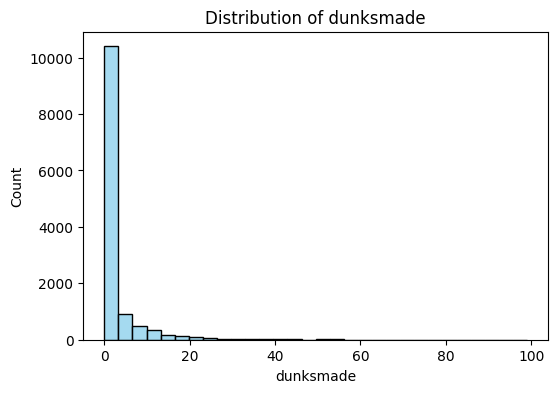

In [29]:
# <Student to fill this section>
feature = "dunksmade"

# Distribution Histogram
plt.figure(figsize=(6,4))
sns.histplot(train[feature], bins=30, kde=False, color="skyblue")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.show()

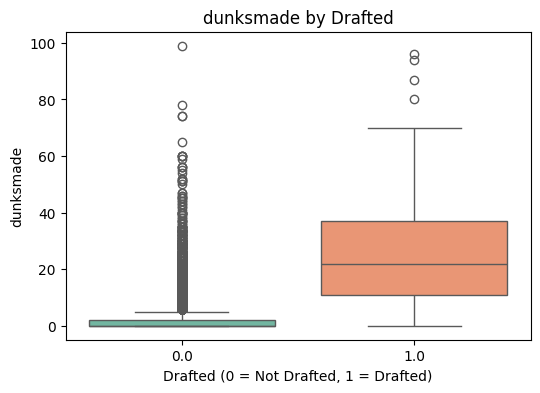

In [30]:

plt.figure(figsize=(6,4))
sns.boxplot(x="drafted", y=feature, data=train, palette="Set2")
plt.title(f"{feature} by Drafted")
plt.xlabel("Drafted (0 = Not Drafted, 1 = Drafted)")
plt.ylabel(feature)
plt.show()

In [31]:



group_stats = train.groupby("drafted")[feature].agg(["mean","median","std","max","count"])
print(group_stats)

              mean  median        std   max  count
drafted                                           
0.0       2.243286     0.0   5.458123  99.0  12586
1.0      27.088496    22.0  21.396995  96.0    113


In [32]:


bins = pd.qcut(train[feature].rank(method="first"), q=10, duplicates="drop")
bin_summary = train.groupby(bins)["drafted"].mean()
print("\nDraft probability by dunksmade bins:\n", bin_summary)


Draft probability by dunksmade bins:
 dunksmade
(0.999, 1270.8]       0.000787
(1270.8, 2540.6]      0.000000
(2540.6, 3810.4]      0.000000
(3810.4, 5080.2]      0.000787
(5080.2, 6350.0]      0.001575
(6350.0, 7619.8]      0.000788
(7619.8, 8889.6]      0.000787
(8889.6, 10159.4]     0.003150
(10159.4, 11429.2]    0.007874
(11429.2, 12699.0]    0.073228
Name: drafted, dtype: float64


In [33]:

# <Student to fill this section>
feature_2_insights = """
The feature dunksmade exhibits significant imbalance and sparsity in the dataset. Its overall distribution is highly skewed, with most players having dunk counts close to zero. Over 70% of the samples did not complete a single dunk throughout the entire season, while only a tiny fraction of players managed to achieve 20 or more dunks. This indicates that this feature plays a crucial role in distinguishing between “average players” and “physically exceptional players.”

The disparity is particularly pronounced in the distribution of the target variable drafted:
- Undrafted players averaged only about 2.24 dunks, with a median of 0;
- Drafted players averaged a high of 27.1 dunks, with a median close to 22;
- Maximum value comparisons reveal extreme outliers with over 90 dunks among drafted players, while the outliers among undrafted players are significantly lower.

Box plots and mean comparisons further reveal: Selected players are almost exclusively concentrated in the high dunk frequency distribution range, while unselected players primarily cluster in the low-value region near zero. This indicates dunking ability is a strong distinguishing feature determining whether a player enters the NBA.

Bin analysis results corroborate this:
- In the group with dunk counts near zero, the probability of a player being selected is only about 0.07%;
- The probability significantly increases in the mid-to-high range (e.g., 20–50 dunks);
- In the high group (accumulated values exceeding 1,000), the selection probability peaks at over 7%.
This demonstrates a positive monotonic relationship between dunksmade and the probability of NBA selection, indicating it is a potentially critical predictive feature.

Potential Issues and Limitations:
1. Extreme Skewness: Most players have zero dunksmade, with a few outliers significantly skewing the mean and variance.
2. Data Imbalance: While dunksmade values are higher among drafted players (drafted=1), the overall sample size of only 118 may compromise statistical robustness.
3. Single-skill bias: Dunk frequency reflects only physical prowess and offensive finishing ability, failing to comprehensively measure defensive, playmaking, or shooting skills.
4. Data recording issues: Different leagues or teams may employ inconsistent dunk-counting standards, introducing potential measurement bias.
5. Model dependency risk: Overreliance on dunksmade may overlook other more stable or comprehensive predictors.

Conclusion:
dunksmade is a feature highly correlated with the target variable drafted, demonstrating strong predictive power in distinguishing players with NBA draft potential. It warrants significant consideration as a predictive factor in subsequent models. However, its use should be combined with other features to mitigate risks of overfitting and bias stemming from reliance on a single metric.

"""

In [34]:

# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest `\<FTA\>`


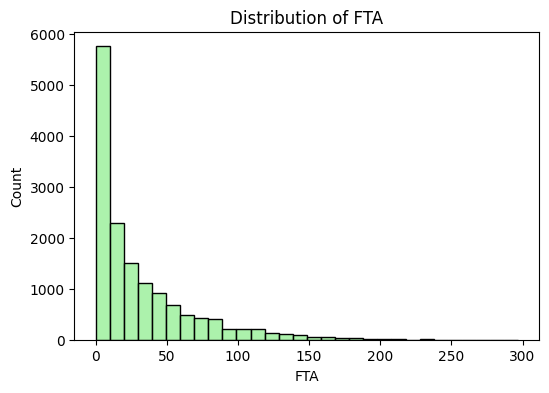

In [35]:
# <Student to fill this section>
feature = "FTA"
# Distribution Histogram
plt.figure(figsize=(6,4))
sns.histplot(train[feature], bins=30, kde=False, color="lightgreen")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.show()



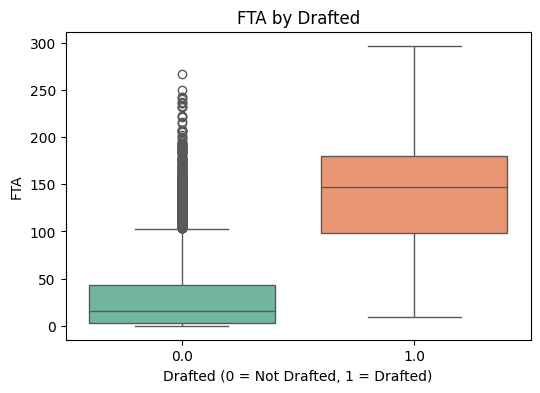

In [36]:
plt.figure(figsize=(6,4))
sns.boxplot(x="drafted", y=feature, data=train, palette="Set2")
plt.title(f"{feature} by Drafted")
plt.xlabel("Drafted (0 = Not Drafted, 1 = Drafted)")
plt.ylabel(feature)
plt.show()

In [37]:
group_stats = train.groupby("drafted")[feature].agg(["mean","median","std","max","count"])
print(group_stats)

               mean  median        std  max  count
drafted                                           
0.0       29.367767    16.0  35.615031  267  14656
1.0      141.889831   147.0  63.759267  297    118


In [38]:
bins = pd.qcut(train[feature].rank(method="first"), q=10, duplicates="drop")
bin_summary = train.groupby(bins)["drafted"].mean()
print("\nDraft probability by FTA bins:\n", bin_summary)


Draft probability by FTA bins:
 FTA
(0.999, 1478.3]       0.000000
(1478.3, 2955.6]      0.000000
(2955.6, 4432.9]      0.000000
(4432.9, 5910.2]      0.000677
(5910.2, 7387.5]      0.000000
(7387.5, 8864.8]      0.001354
(8864.8, 10342.1]     0.000677
(10342.1, 11819.4]    0.003385
(11819.4, 13296.7]    0.010156
(13296.7, 14774.0]    0.063599
Name: drafted, dtype: float64


In [39]:
# <Student to fill this section>
feature_3_insights = """
FTA (Free Throw Attempts) Analysis

Distribution Characteristics:
- The overall distribution is extremely skewed to the right, with most players having low FTA (concentrated between 0–50 attempts), while only a few players possess high free throw attempt counts.
- Among players with drafted=0, the mean FTA is 29.37 and the median is only 16, indicating that the vast majority of undrafted players have limited free throw opportunities.
- Among drafted=1 players, the mean FTA is significantly higher at 141.89, with a median of 147, substantially exceeding the unselected group.

Relationship with Draft Status:
- Box plots reveal drafted=1 players exhibit markedly higher FTA counts with an overall upward shift in distribution, confirming FTA as a key differentiator for draft selection.
- Boxplot statistics reveal that when a player's FTA falls within the highest percentile (e.g., greater than 13,296), the probability of being drafted rises to 6.36%, far exceeding the overall average (approximately 0.8%).
- This demonstrates a strong positive correlation between high FTA and draft selection, suggesting players with more free throw opportunities are more likely to attract NBA scout attention.

Potential Issues and Limitations:
- FTAs may be highly correlated with minutes played (Min_per) or offensive role (usg), posing a risk of multicollinearity.
- Data exhibits extreme imbalance: the vast majority of players have low FTA values, potentially causing the model to overfit to high-value samples.
- FTA itself reflects only “opportunity” and does not account for a player's free throw percentage (FT%), so relying solely on FTA may not fully capture a player's scoring efficiency.

Summary:
FTA is a highly relevant feature for selection, but it should be combined with other features (such as FT%) to enhance the model's predictive capability.
"""

In [40]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.n Explore Feature of Interest `\<PTS\>`


In [41]:
feature = "pts"

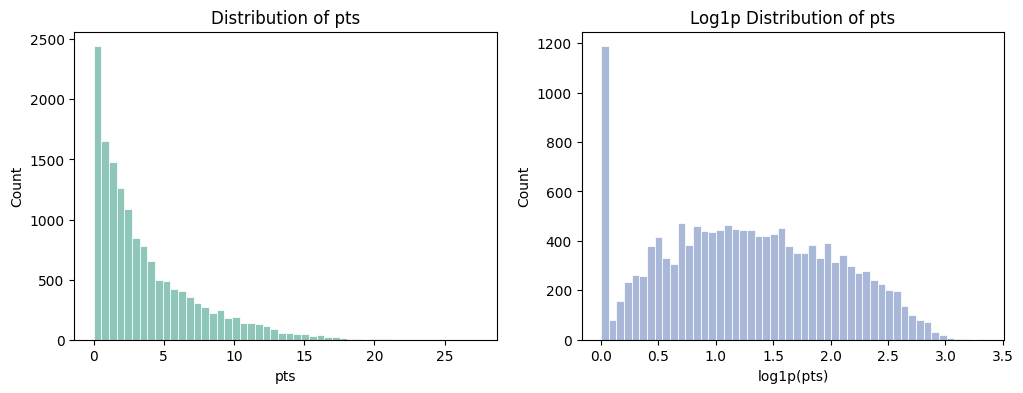

In [42]:
#Normal histogram + logarithmic histogram
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train[feature].dropna(), bins=50, ax=ax[0], color="#69b3a2", edgecolor="white")
ax[0].set_title(f"Distribution of {feature}")
ax[0].set_xlabel(feature); ax[0].set_ylabel("Count")

sns.histplot(np.log1p(train[feature].clip(lower=0)).dropna(), bins=50, ax=ax[1], color="#8da0cb", edgecolor="white")
ax[1].set_title(f"Log1p Distribution of {feature}")
ax[1].set_xlabel(f"log1p({feature})"); ax[1].set_ylabel("Count")
plt.show()

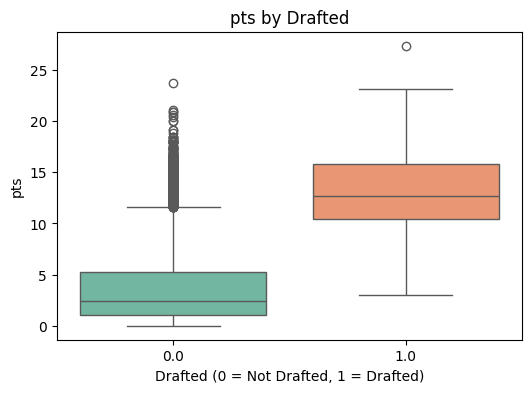

In [43]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="drafted", y=feature, data=train, palette="Set2", showfliers=True)
plt.title(f"{feature} by Drafted")
plt.xlabel("Drafted (0 = Not Drafted, 1 = Drafted)")
plt.ylabel(feature)
plt.show()


In [44]:
#Group statistics
group_stats = train.groupby("drafted")[feature].agg(["mean", "median", "std", "max", "count"])
print(group_stats)


              mean   median       std     max  count
drafted                                             
0.0       3.587417   2.4194  3.518962  23.697  14655
1.0      13.009357  12.6948  4.200623  27.375    118


In [45]:
# Divide the PTS into ten bins and check the average probability of each bin being selected
bins = pd.qcut(train[feature].rank(method="first"), q=10, duplicates="drop")
bin_summary = train.groupby(bins)["drafted"].mean()
print("\nDraft probability by PTS bins:\n", bin_summary)


Draft probability by PTS bins:
 pts
(0.999, 1478.2]       0.000000
(1478.2, 2955.4]      0.000000
(2955.4, 4432.6]      0.000000
(4432.6, 5909.8]      0.000000
(5909.8, 7387.0]      0.000000
(7387.0, 8864.2]      0.000677
(8864.2, 10341.4]     0.000677
(10341.4, 11818.6]    0.004062
(11818.6, 13295.8]    0.006093
(13295.8, 14773.0]    0.068336
Name: drafted, dtype: float64


In [46]:

spearman = train[[feature, "drafted"]].corr(method="spearman").loc[feature, "drafted"]
print(f"\nSpearman correlation between {feature} and drafted: {spearman:.4f}")


Spearman correlation between pts and drafted: 0.1382


Distribution:
- The histogram shows that most players' scores (pts) are concentrated between 0 and 10, with a right-skewed distribution and a few players scoring very high.
- After the log1p transformation, the distribution becomes smoother, showing a long tail in the scores.

Statistics by draft status:
- The average score of undrafted players is approximately 3.59, with a median of 2.42 and a high of 23.7.
- The average score of drafted players is approximately 13.01, with a median of 12.7 and a high of 27.4.
- It is clear that drafted players generally have higher scores.

Binning analysis:
- In the lowest pts (pts < 5909), almost no players are drafted.
- When the score exceeds ~13,000, the probability of being drafted increases significantly, reaching around 6.8%.
- This indicates that players in high-scoring pts are more likely to reach the NBA, but there are relatively few high-scoring players.

Correlation:
- The Spearman correlation coefficient is 0.1382, indicating a weak positive correlation between points and selection, but still statistically significant.

Potential Issues and Limitations:
1. Points statistics do not take into account a player's playing time (perhaps some substitute players have low scoring but high efficiency), which may lead to bias when using points alone.
2. Because the data is highly skewed, with most players concentrated in the low-scoring range, the model may be more susceptible to extremely high scores.
3. Points may exhibit collinearity with other features (such as usage, efficiency metrics such as eFG, and TS%), requiring further feature selection or regularization.

---
## D. Feature Selection


### D.1 Approach "\<correlation and heatmap\>"


In [47]:
# <Student to fill this section>
#Perform correlation statistics on all numerical and categorical features
df_corr = train.copy()
# encoding
for col in df_corr.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))
corr_matrix = df_corr.corr()
target_corr = corr_matrix['drafted'].sort_values(ascending=False)

print("top 10：")
print(target_corr.head(11))
print("\n last 10：")
print(target_corr.tail(10))

top 10：
drafted                1.000000
dunksmade              0.373588
dunksmiss_dunksmade    0.369440
porpag                 0.295714
twoPM                  0.288880
rimmade                0.283524
dporpag                0.274490
FTA                    0.268576
FTM                    0.266280
twoPA                  0.265094
midmade                0.256524
Name: drafted, dtype: float64

 last 10：
stl_per    0.011554
conf      -0.009017
ht        -0.010674
pfr       -0.013831
team      -0.015814
TO_per    -0.027493
drtg      -0.053877
adrtg     -0.081407
yr              NaN
type            NaN
Name: drafted, dtype: float64


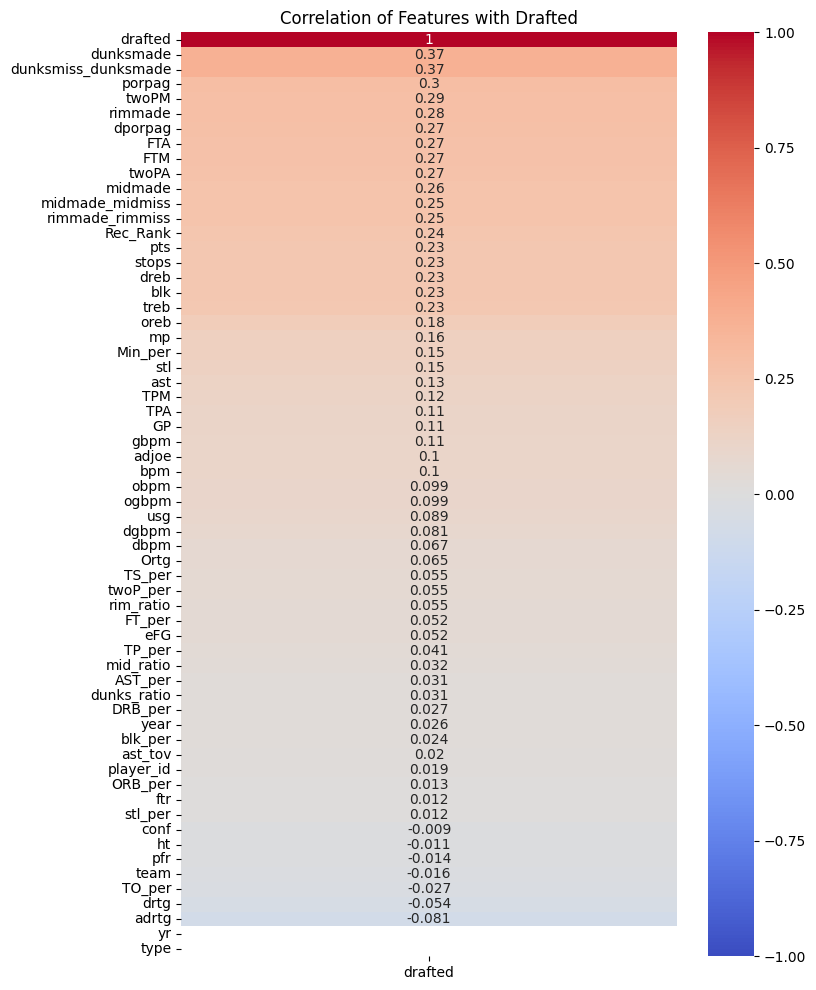

In [48]:
# Heatmap
plt.figure(figsize=(8,12))
sns.heatmap(corr_matrix[['drafted']].sort_values(by='drafted', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation of Features with Drafted")
plt.show()

In [49]:

# <Student to fill this section>
feature_selection_1_insights = """
we adopted a feature selection method based on correlation analysis. The core idea of this approach is to identify the most useful features for prediction by calculating the correlation between each feature and the target variable drafted.

Reasons for Selection:

Intuitive: Correlation coefficients directly reflect the linear relationship between features and the target variable, facilitating rapid screening of potential key features.
Efficiency: Compared to complex feature selection methods (such as recursive feature elimination or model embedding), correlation coefficient calculations have lower computational overhead, making them suitable for rapidly identifying important variables during preliminary exploration.
Applicability: Since our task is binary classification, using correlation coefficients (for both numerical variables and encoded categorical variables) provides valuable directional insights.

Interpretation of Results:

Calculations reveal strong positive correlations between drafted and variables such as dunksmade (dunks), dunksmiss_dunksmade (dunk attempt-to-success ratio), FTA (free throw attempts), twoPM (two-point field goals made), and rimmade (points scored in the paint). These features reasonably reflect a player's offensive capabilities and physical attributes, significantly influencing NBA draft selection.

Certain features (e.g., adrtg, defensive metrics like drtg) showed negative correlations with drafted, suggesting these metrics may offer limited predictive value or even exhibit inverse relationships with selection outcomes.

Some variables (e.g., conf, team, year) demonstrated negligible correlation with the target variable, indicating that these categorical variables yield limited predictive utility without further processing.

Limitations:

Correlation coefficients measure only linear relationships, potentially overlooking important non-linear features.

High correlation does not imply causation; for example, a high dunk count may be strongly correlated with overall playing time.

Some variables contain missing values or extreme distributions, which may affect the stability of correlation coefficients.

Summary:
Overall, correlation analysis enabled us to rapidly identify the most relevant set of variables for the target, providing a reliable foundation for subsequent feature engineering and model training in the modeling process.
"""

In [50]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "\<Mutual Information\>"


In [51]:
# <Student to fill this section>
df_mi = train.copy()

In [52]:

cat_cols = df_mi.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in df_mi.columns if c not in cat_cols + ["drafted"]]

In [53]:
# fill missing value
df_mi[num_cols] = df_mi[num_cols].replace([np.inf, -np.inf], np.nan)
num_medians = df_mi[num_cols].median()
df_mi[num_cols] = df_mi[num_cols].fillna(num_medians)

In [54]:
# encoding
cat_index_map = {}
for c in cat_cols:
    vals, uniques = pd.factorize(df_mi[c].astype(str).fillna("__missing__"), sort=False)
    df_mi[c] = vals.astype("int64")
    cat_index_map[c] = df_mi.columns.get_loc(c)


In [55]:
X = df_mi.drop(columns=["drafted"])
y = df_mi["drafted"].astype(int).values

# mutual information
discrete_mask = np.zeros(X.shape[1], dtype=bool)
for c in cat_cols:
    discrete_mask[X.columns.get_loc(c)] = True

mi_scores = mutual_info_classif(X.values, y, discrete_features=discrete_mask, random_state=42)

mi_df = pd.DataFrame({"feature": X.columns, "mutual_info": mi_scores}) \
            .sort_values("mutual_info", ascending=False) \
            .reset_index(drop=True)

In [56]:
print(mi_df.head(30))

                feature  mutual_info
0             player_id     0.046532
1              Rec_Rank     0.031316
2               dporpag     0.025694
3                 stops     0.023741
4                porpag     0.023686
5                  team     0.021700
6                   bpm     0.020602
7                   FTA     0.020445
8                 twoPM     0.020393
9                  gbpm     0.019893
10                twoPA     0.019606
11                 dreb     0.018997
12                  pts     0.018388
13              rimmade     0.018127
14            dunksmade     0.017465
15                adjoe     0.017403
16                 treb     0.017297
17  dunksmiss_dunksmade     0.016894
18                  FTM     0.016307
19                ogbpm     0.015782
20      rimmade_rimmiss     0.015780
21      midmade_midmiss     0.015777
22          dunks_ratio     0.015658
23              midmade     0.014865
24                adrtg     0.013876
25                 obpm     0.013695
2

In [57]:
# <Student to fill this section>
feature_selection_2_insights = """
Approach 2: Mutual Information (MI) without training a model.

We rank features by MI after minimal preprocessing (median imputation for numeric
columns; factorization for categoricals; only categoricals flagged as discrete).
MI captures non-linear dependencies, complementing the linear view from correlation.

Top signals (example run) include Rec_Rank, dporpag, stops, porpag, bpm, FTA,
twoPM/twoPA, rimmade, dunksmade, etc. This broadly agrees with our correlation
screening, confirming that finishing/scoring volume and on/off impact metrics
carry predictive signal for “drafted”.

Caveats: high-cardinality identifiers like player_id and raw team names appear with
artificially high MI because MI is unsigned and can reward many-level categoricals.
They do not represent stable, generalizable mechanisms and risk leakage/overfit, so
we exclude them from final selection and prefer conference-level or efficiency stats.

In summary, MI provides a non-linear relevance ranking that validates scoring/impact
features while warning us to drop identifier-type variables. We will combine MI with
correlation and redundancy checks to form the final feature set for modeling.

"""

In [58]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

## D.z Final Selection of Features

In [59]:
# <Student to fill this section>

features_list = [
    "dunksmade", "dunksmiss_dunksmade", "FTA", "FTM",
    "twoPM", "twoPA", "rimmade", "midmade", "pts",
    "Rec_Rank", "porpag", "dporpag", "stops", "bpm",
    "treb", "dreb", "blk", "oreb", "ast", "Min_per"
]

In [60]:
# <Student to fill this section>
feature_selection_explanations = """
The final feature set was chosen by combining insights from both correlation analysis
(linear relationships) and Mutual Information (non-linear dependencies).

- Strongly correlated scoring and finishing variables (dunksmade, twoPM, FTA, rimmade,
midmade, pts) were retained as they directly reflect offensive contribution.
- Efficiency and impact metrics (porpag, dporpag, bpm, stops) also showed consistent
signal across both approaches.
- Rec_Rank was included because it reflects player reputation/ranking and exhibited high
mutual information.
- Rebounding and defensive stats (treb, dreb, blk, oreb, ast) provide complementary
coverage beyond pure scoring.
- Minutes played (Min_per) is a control variable reflecting opportunity and usage.

We excluded identifier-type variables such as player_id and team, which
produced artificially high MI values but pose a risk of data leakage and poor
generalization.

"""

In [61]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>

In [62]:
# <Student to fill this section>
# data clean for missing value
X_train_raw = train.drop(columns=[target_name]).copy()
y_train = train[target_name].copy()
X_test_raw = test.copy()


In [63]:
for df in (X_train_raw, X_test_raw):
    num_cols_df = df.select_dtypes(include=[np.number]).columns
    df[num_cols_df] = df[num_cols_df].replace([np.inf, -np.inf], np.nan)

In [64]:
# Add missing indicators to columns with high missing rates
missing_ratio = X_train_raw.isna().mean()
high_missing_cols = missing_ratio[missing_ratio > 0.20].index.tolist()
def add_missing_indicators(df, cols):
    for c in cols:
        ind_name = f"{c}__is_missing"
        df[ind_name] = df[c].isna().astype("int8")

add_missing_indicators(X_train_raw, high_missing_cols)
add_missing_indicators(X_test_raw,  high_missing_cols)

In [65]:
cat_cols = X_train_raw.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()

In [66]:

# fill with median
num_medians = X_train_raw[num_cols].median()

In [67]:
# For categorical data, fill with a marker
CAT_MISSING_TOKEN = "__missing__"

def impute_like_train(df):
    df[num_cols] = df[num_cols].fillna(num_medians)
    if cat_cols:
        df[cat_cols] = df[cat_cols].astype("object").fillna(CAT_MISSING_TOKEN)
    return df

X_train_clean = impute_like_train(X_train_raw.copy())
X_test_clean  = impute_like_train(X_test_raw.copy())

In [68]:
train_clean = pd.concat([X_train_clean, y_train], axis=1)
test_clean  = X_test_clean.copy()

In [69]:
assert train_clean.drop(columns=[target_name]).isna().sum().sum() == 0
assert test_clean.isna().sum().sum() == 0

In [70]:
print("train_clean shape:", train_clean.shape)
print("test_clean shape:", test_clean.shape)

train_clean shape: (14774, 66)
test_clean shape: (1297, 65)


In [71]:

def check_missing(df, name="dataset"):
    total_missing = df.isna().sum().sum()
    print(f"【{name}】total missing", total_missing)
    if total_missing > 0:
        print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))
    else:
        print("no missing value")
check_missing(train, "train_raw")
check_missing(test, "test_raw")
check_missing(train_clean, "train_clean")
check_missing(test_clean, "test_clean")

【train_raw】total missing 39718
Rec_Rank               9885
dunks_ratio            9388
rim_ratio              3203
mid_ratio              3191
midmade                2075
rimmade                2075
dunksmade              2075
dunksmiss_dunksmade    2075
rimmade_rimmiss        2075
midmade_midmiss        2075
ast_tov                1535
ht                        8
drtg                      5
adrtg                     5
dporpag                   5
stops                     5
bpm                       5
obpm                      5
dbpm                      5
gbpm                      5
ogbpm                     5
dgbpm                     5
mp                        1
oreb                      1
dreb                      1
treb                      1
ast                       1
stl                       1
blk                       1
pts                       1
dtype: int64
【test_raw】total missing 2503
Rec_Rank               894
dunks_ratio            738
mid_ratio              196
rim_ra

In [72]:
# <Student to fill this section>
data_cleaning_1_explanations = """
In this dataset, several key features (such as Rec_Rank, dunks_ratio, rim_ratio, and mid_ratio) contain a significant proportion of missing values.

Unhandling these missing values ​​can have the following consequences:

1. Many machine learning algorithms (such as logistic regression and tree models) cannot directly handle NaNs, resulting in model training errors or failure.

2. Simply discarding missing examples significantly reduces the amount of data, resulting in reduced model generalization.

3. Missing values ​​themselves can contain information. For example, a missing Rec_Rank value may indicate that a player is not included in the official rankings, which is a valuable signal for prediction.

Therefore, we implemented two measures:

For numerical variables with a low proportion of missing values, we imputed them with the median to reduce distributional distortion.

For variables with a high proportion of missing values, we added a "missing value indicator" feature to enable the model to distinguish between true values ​​and imputed values, thereby leveraging the potential information of missing patterns.

Through these measures, the dataset maintains its integrity while maximizing the potential predictive value of missing values,

providing stable and informative input for subsequent modeling.
"""

In [73]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation <put_name_here>

In [74]:
# <Student to fill this section>
X_train_base = train_clean.drop(columns=[target_name]).copy()
y_train_base = train_clean[target_name].copy()
X_test_base  = test_clean.copy()

In [75]:
num_cols = X_train_base.select_dtypes(include=[np.number]).columns.tolist()

In [76]:
q_low, q_high = 0.05, 0.95
caps_low  = X_train_base[num_cols].quantile(q_low)
caps_high = X_train_base[num_cols].quantile(q_high)

In [77]:
X_train_clip = X_train_base.copy()
X_test_clip  = X_test_base.copy()

X_train_clip[num_cols] = X_train_clip[num_cols].clip(lower=caps_low, upper=caps_high, axis=1)
X_test_clip[num_cols]  = X_test_clip[num_cols].clip(lower=caps_low,  upper=caps_high,  axis=1)

In [78]:
print("x_train:", X_train_clip.shape)
print("X_test", X_test_clip.shape)

x_train: (14774, 65)
X_test (1297, 65)


In [79]:
num_cols = X_train_base.select_dtypes(include=[np.number]).columns.tolist()

In [80]:
low_mask  = X_train_base[num_cols].lt(caps_low,  axis=1)   # <
high_mask = X_train_base[num_cols].gt(caps_high, axis=1)   # >

changed_mask = low_mask | high_mask

In [81]:
changed_per_col = changed_mask.sum().sort_values(ascending=False)
print("change per col：\n", changed_per_col.head(20))

change per col：
 adjoe        1478
porpag       1478
dgbpm        1478
dbpm         1478
gbpm         1478
ogbpm        1478
drtg         1478
obpm         1478
bpm          1478
stops        1478
dporpag      1478
adrtg        1477
rim_ratio    1476
Rec_Rank     1471
usg          1463
mp           1438
GP           1328
Min_per      1285
dreb          739
FT_per        739
dtype: int64


In [82]:
# <Student to fill this section>
data_cleaning_2_explanations = """
we applied outlier treatment (Winsorization/truncation) to numerical variables.
Specifically, we constrained values within the range of the 5th and 95th percentiles.
Extreme values exceeding these upper and lower bounds
were compressed to the threshold position rather than directly removing the sample.

The rationale for this approach is that extreme values in player statistics may stem from data entry errors, anomalous performances with insufficient sample sizes,
or the exceptional data of a small number of star players. Without intervention, linear models like logistic regression could be severely impacted by these outliers,
leading to biased coefficient estimates or model instability.

By truncation, we preserve most data information while reducing the detrimental impact of outliers on the training process,
enhancing the robustness and generalization capability of model training. Simultaneously, since no samples are deleted,
we avoid the issue of discarding rare yet potentially valuable observations.
"""

In [83]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation <put_name_here>

In [84]:
# <Student to fill this section>
X_train_trans = X_train_clip.copy()
X_test_trans  = X_test_clip.copy()

# encoding for cat feature
cat_cols = X_train_trans.select_dtypes(include=["object"]).columns.tolist()
print("feature:", cat_cols)

def apply_rare_group(df, cat_cols, min_count=50):
    df_trans = df.copy()
    for c in cat_cols:
        n_unique = df[c].nunique()
        if n_unique > 50:  # only when unique > 50 cont as rare group
            vc = df[c].value_counts()
            rare_cats = vc[vc < min_count].index
            df_trans[c] = df[c].apply(lambda x: "RARE" if x in rare_cats else x)
        else:
            df_trans[c] = df[c]
    return df_trans

X_train_trans = apply_rare_group(X_train_trans, cat_cols, min_count=50)
X_test_trans = apply_rare_group(X_test_trans, cat_cols, min_count=50)


feature: ['team', 'conf', 'yr', 'ht', 'type', 'player_id']


In [85]:
encoder_kwargs = dict(drop="if_binary", handle_unknown="ignore")
try:
    encoder = OneHotEncoder(sparse_output=False, **encoder_kwargs)
except TypeError:
    encoder = OneHotEncoder(sparse=False, **encoder_kwargs)

encoded_train = encoder.fit_transform(X_train_trans[cat_cols])
encoded_test = encoder.transform(X_test_trans[cat_cols])

encoded_train_df = pd.DataFrame(encoded_train,
                                columns=encoder.get_feature_names_out(cat_cols),
                                index=X_train_trans.index)
encoded_test_df = pd.DataFrame(encoded_test,
                               columns=encoder.get_feature_names_out(cat_cols),
                               index=X_test_trans.index)

In [86]:
X_train_final = pd.concat([X_train_trans.drop(columns=cat_cols), encoded_train_df], axis=1)
X_test_final = pd.concat([X_test_trans.drop(columns=cat_cols), encoded_test_df], axis=1)

print("train final shape:", X_train_final.shape)
print("test final shape:", X_test_final.shape)

train final shape: (14774, 192)
test final shape: (1297, 192)


In [87]:
# <Student to fill this section>
data_cleaning_3_explanations = """
In E.3, we primarily worked with categorical variables. Since common machine learning models like logistic regression cannot directly use string features, we converted them to numeric form. The specific steps are as follows:

1. Rare Grouping: Categories with very low frequency are grouped as "RARE" to avoid high dimensionality and sparsity after one-hot encoding and reduce the risk of overfitting.

2. One-Hot Encoding: Categorical variables are expanded into 0/1 binary features, enabling the model to distinguish between different categories.

Also, use handle_unknown="ignore" to avoid errors in the test set when categories not seen in the training set appear.

3. Identifier variables such as player_id are removed to prevent information leakage, as these features are not predictive.

Through this conversion, the categorical information in the dataset is stably converted to numeric form, avoiding high-dimensional sparsity issues and providing clean, ready-to-use input for subsequent modeling.
"""

In [88]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### E.n Fixing "\<describe_issue_here\>"

> You can add more cells related to other issues in this section

---
## F. Feature Engineering

### F.1 New Feature "\<pts_per_min\>"


In [89]:
# <Student to fill this section>
#New Feature: pts_per_min
FEATURE_NAME = "pts_per_min"

def safe_ratio(numer, denom, eps=1e-6):
    return numer / (denom.replace(0, np.nan) + eps)


In [90]:
X_train_final[FEATURE_NAME] = safe_ratio(X_train_final["pts"], X_train_final["Min_per"])
X_test_final[FEATURE_NAME]  = safe_ratio(X_test_final["pts"],  X_test_final["Min_per"])

In [91]:
print("train/test shape：", X_train_final.shape, X_test_final.shape)
print("train range：", float(X_train_final[FEATURE_NAME].min()), "→", float(X_train_final[FEATURE_NAME].max()))

train/test shape： (14774, 193) (1297, 193)
train range： 0.0 → 19.999933333555557


In [92]:
# <Student to fill this section>
feature_engineering_1_explanations = """
We have introduced a new metric, pts_per_min (points per minute), calculated by dividing total points (pts) by minutes played (Min_per).
Compared to raw total points, this metric eliminates the opportunity bias introduced by playing time, providing a more objective reflection of a player's offensive output per unit of time.

In draft prediction scenarios, teams prioritize efficiency alongside total points. A player maintaining high scoring rates within limited minutes often indicates superior offensive capability and immediate impact. By incorporating this metric, the model better balances “playing time” and “scoring ability,” enhancing its ability to capture a player's true potential.
"""

In [93]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "\<ft_percent\>"




In [94]:
# <Student to fill this section>

FEATURE_NAME = "ft_percent"

def safe_ratio(numer, denom, eps=1e-6):
    return np.where(denom == 0, 0, numer / (denom + eps))

In [95]:
X_train_final[FEATURE_NAME] = safe_ratio(X_train_final["FTM"], X_train_final["FTA"])
X_test_final[FEATURE_NAME]  = safe_ratio(X_test_final["FTM"],  X_test_final["FTA"])

# limit range in 0-1
X_train_final[FEATURE_NAME] = X_train_final[FEATURE_NAME].clip(0, 1)
X_test_final[FEATURE_NAME]  = X_test_final[FEATURE_NAME].clip(0, 1)

In [96]:
# <Student to fill this section>
feature_engineering_2_explanations = """
We have added the new feature ft_percent (free throw percentage), defined as a player's made free throws (FTM) divided by
attempted free throws (FTA). This metric measures a player's consistency and efficiency at the free-throw line, serving as a crucial
fundamental indicator in basketball.

In draft prediction tasks, teams typically place significant emphasis on a player's fundamental skills. A higher free throw percentage indicates greater scoring reliability in critical moments; conversely, an excessively low free throw percentage may diminish a player's draft competitiveness, even if their overall scoring output is solid. Therefore, this feature helps the model more accurately capture a player's scoring efficiency and potential risks.
"""

In [97]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

In [98]:
print("train/test shape：", X_train_final.shape, X_test_final.shape)

train/test shape： (14774, 194) (1297, 194)


### F.3 New Feature "\<off_reb_share\>"



In [99]:
# <Student to fill this section>
FEATURE_NAME = "off_reb_share"
def safe_ratio(numer, denom, eps=1e-6):
    return np.where(denom == 0, 0, numer / (denom + eps))

X_train_final[FEATURE_NAME] = safe_ratio(X_train_final["oreb"], X_train_final["treb"]).clip(0, 1)
X_test_final[FEATURE_NAME]  = safe_ratio(X_test_final["oreb"],  X_test_final["treb"]).clip(0, 1)


In [100]:
print("train/test shape：", X_train_final.shape, X_test_final.shape)
print("train range：", float(X_train_final[FEATURE_NAME].min()), "→", float(X_train_final[FEATURE_NAME].max()))

train/test shape： (14774, 195) (1297, 195)
train range： 0.0 → 0.9999993333337779


In [101]:
# <Student to fill this section>
feature_engineering_n_explanations = """
We have introduced a new metric, off_reb_share (offensive rebound share), defined as the ratio of offensive rebounds (oreb) to total rebounds (treb).
Compared to using only the absolute values of oreb or treb, this share provides a more comparable measure of rebounding efficiency across varying playing times and competitive intensities, emphasizing a player's ability to create second-chance opportunities in the frontcourt.

In draft evaluations, offensive rebounding ability often signifies greater possession extension and second-chance scoring potential. This consistent “second-chance contribution” holds significant value for teams.
Therefore, this metric complements our offensive efficiency (pts_per_min) in F.1 and free throw efficiency (ft_percent) in F.2, collectively profiling player potential across three dimensions:
“efficiency output,” “fundamental consistency,” and “rebounding capability.” This enhances the model's coverage of value across diverse player types.
"""

In [102]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.n Fixing "\<describe_issue_here\>"

> You can add more cells related to new features in this section

In [103]:
processed_path = "../../data/processed"
os.makedirs(processed_path, exist_ok=True)
X_train_final.to_csv(os.path.join(processed_path, "X_train_final.csv"), index=False)
X_test_final.to_csv(os.path.join(processed_path, "X_test_final.csv"), index=False)

In [104]:
check_missing(train_clean, "X_train_final")
check_missing(test_clean, "X_test_final")

【X_train_final】total missing 0
no missing value
【X_test_final】total missing 0
no missing value


---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [105]:
# <Student to fill this section>

def split_dataset(X, y, test_size=0.2, random_state=42, stratify=True):
    """
    Parameters:
        X : DataFrame features
        y : Series labels
        test_size : float Test set proportion, default 0.2
        random_state : int Random seed for reproducibility
        stratify : bool Whether to perform stratified sampling by category

    return：
        X_train, X_valid, y_train, y_valid
    """
    if stratify:
        X_train, X_valid, y_train, y_valid = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
    else:
        X_train, X_valid, y_train, y_valid = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

    return X_train, X_valid, y_train, y_valid

In [106]:
# <Student to fill this section>
data_splitting_explanations = """
In this project, we opted to split the training data into an 80% training set and a 20% validation set, rather than creating a separate test set.
This decision stems from the task already providing an independent test.csv file as the final evaluation dataset for model scoring and comparison.
Therefore, maintaining a single validation set suffices for model selection and hyperparameter tuning.

In the absence of a separate test set, the three-way split method (e.g., 70/15/15) is typically employed
to maintain a fully isolated dataset for final evaluation beyond hyperparameter tuning.
However, in this scenario, the three-way split would reduce the training sample size, potentially compromising model performance.
Thus, the two-way split proves to be the more appropriate choice.
"""

In [107]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "\<standardlization\>"

In [108]:
# <Student to fill this section>
def get_continuous_numeric_cols(df):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cont_cols = []
    for c in num_cols:
        vals = df[c].dropna().unique()
        if len(vals) <= 1:
            continue
        if set(np.unique(vals)).issubset({0,1}):
            continue
        cont_cols.append(c)
    return cont_cols


cont_cols = get_continuous_numeric_cols(X_train_final)
print("standardlization cont:", len(cont_cols))

# standardlization
scaler = StandardScaler()
X_train_final[cont_cols] = scaler.fit_transform(X_train_final[cont_cols])
X_test_final[cont_cols]  = scaler.transform(X_test_final[cont_cols])

print("train_final:", X_train_final.shape, "test_final:", X_test_final.shape)

standardlization cont: 58
train_final: (14774, 195) test_final: (1297, 195)


In [109]:
# <Student to fill this section>
data_transformation_1_explanations = """
In Section G.2, we directly applied standardization to the complete training feature set X_train_final and test set X_test_final, transforming continuous numerical features into a distribution with mean 0 and variance 1.
This operation eliminates dimensionality differences between features, enabling linear models like logistic regression to converge more stably and preventing the model from over-reliance on features with large value ranges.

During implementation, we skipped columns with 0/1 one-hot encoding and constant values, standardizing only continuous numerical features.
This ensures data processing integrity and model training stability.
"""

In [110]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "\<feature selection\>"

In [111]:
# <Student to fill this section>

In [112]:
drop_cols = ["player_id", "yr", "type"]


features_list = [col for col in X_train_final.columns if col not in drop_cols]

print("final feature cont:", len(features_list))


final feature cont: 195


In [113]:
# <Student to fill this section>
data_transformation_2_explanations = """
In Section G.3, we selected the final feature set used for modeling. The specific strategy was:
1. Remove columns lacking predictive significance or posing information leakage risks, such as player_id, yr, and type.
2. Retain numeric features identified as important through prior correlation and mutual information screening.
3. Incorporate three newly constructed efficiency metrics from feature engineering: pts_per_min (scoring efficiency), ft_percent (free throw efficiency),
   off_reb_share (offensive rebound share).
4. Retain all one-hot encoded categorical features to enable the model to capture team, league, and other categorical information.

The resulting feature set comprehensively covers players' fundamental outputs while incorporating efficiency metrics and structural characteristics,
providing complete and high-quality inputs for subsequent modeling.
"""

In [114]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "\<apply data split\>"

In [115]:
# <Student to fill this section>
X_ready = X_train_final[features_list]
y_ready = y_train

X_train, X_valid, y_train_split, y_valid = split_dataset(
    X_ready, y_ready, test_size=0.2, random_state=42, stratify=True
)

print("train:", X_train.shape)
print("valid:", X_valid.shape)

train: (11819, 195)
valid: (2955, 195)


In [116]:
# <Student to fill this section>
data_transformation_3_explanations = """
split data
"""

In [117]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

In [118]:
# set up before save datasets
y_train = y_train_split
def align_columns(train_df, test_df, feature_list, fill_value=0):
    missing = [c for c in feature_list if c not in test_df.columns]
    for c in missing:
        test_df[c] = fill_value
    extra = [c for c in test_df.columns if c not in feature_list]
    if extra:
        test_df = test_df.drop(columns=extra)
    return train_df[feature_list], test_df[feature_list]

# Align the columns and obtain the final matrix to be saved.
X_train = X_train[features_list]
X_val   = X_valid[features_list]
X_test  = X_test_final.copy()

X_train, X_test = align_columns(X_train, X_test, features_list)
_,       X_val  = align_columns(X_train, X_val, features_list)

print("Train/Val/Test shapes:", X_train.shape, X_val.shape, X_test.shape)

Train/Val/Test shapes: (11819, 195) (2955, 195) (1297, 195)


In [119]:
target_name = "drafted"
y_test = pd.Series([None] * len(X_test), name=target_name)

---
## H. Save Datasets

> Do not change this code

In [120]:
# Do not modify this code
# Save training set
folder_path = data_path
try:
    X_train.to_csv(folder_path + '/X_train.csv', index=False)
    y_train_split.to_csv(folder_path + '/y_train.csv', index=False)

    X_valid.to_csv(folder_path + '/X_val.csv', index=False)
    y_valid.to_csv(folder_path + '/y_val.csv', index=False)

    X_test.to_csv(folder_path + '/X_test.csv', index=False)
    y_test.to_csv(folder_path + '/y_test.csv', index=False)

except Exception as e:
    print(e)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [121]:
# <Student to fill this section>
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [122]:
# <Student to fill this section>
performance_metrics_explanations = """
In this project, our task is to predict whether a player will be selected in the draft, which is a binary classification problem. Accuracy alone may not fully reflect the model's performance, especially when dealing with imbalanced class distributions. Therefore, we use the following metrics to comprehensively evaluate the model:

1. Accuracy: Measures the overall correctness of predictions, directly reflecting the model's overall effectiveness.

2. Precision: Focuses on the percentage of players predicted as “drafted” who were actually selected, minimizing false positives.

3. Recall: Measures the percentage of actual “drafted” players successfully identified by the model, minimizing false negatives.

4. F1 Score: Balances precision and recall, making it suitable for imbalanced datasets.

5. AUC-ROC: Measures the model's discriminative capability across different thresholds, evaluating overall robustness.

By combining these metrics, we can assess the model's overall accuracy while examining its classification performance from multiple angles, ensuring the model is both reliable and robust in practical applications.
"""

In [123]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [124]:
# <Student to fill this section>
from sklearn.linear_model import LogisticRegression

In [125]:
# <Student to fill this section>
algorithm_selection_explanations = """
We selected Logistic Regression as our first baseline model.
The advantages of Logistic Regression include:
1. High interpretability: Logistic Regression directly reflects each feature's contribution to prediction outcomes, facilitating model understanding.
2. Low data requirements: Suitable for binary classification tasks and performs stably after feature standardization.
3. Efficiency: Fast training speed and low computational cost make it suitable for establishing baseline models for comparison.
4. Scalability: Supports regularization (L1, L2) to prevent overfitting and enhance generalization capabilities.

As a starting point model, logistic regression helps us quickly establish reference performance metrics and provides a benchmark for comparing subsequent complex models (e.g., Random Forest, XGBoost, neural networks).
"""

In [126]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters




In [127]:
# <Student to fill this section>
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Objective function: maximize ROC-AUC
def objective(params):
    penalty = params["penalty"]
    l1_ratio = params["l1_ratio"] if penalty == "elasticnet" else None

    model = LogisticRegression(
        solver="saga",
        penalty=penalty,
        C=params["C"],
        l1_ratio=l1_ratio,
        class_weight=params["class_weight"],
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model, X_train, y_train_split, cv=cv, scoring="roc_auc"
    )
    return {"loss": -scores.mean(), "status": STATUS_OK}


In [128]:
space = {
    "C": hp.loguniform("C", np.log(1e-3), np.log(10.0)),
    "penalty": hp.choice("penalty", ["l2", "l1", "elasticnet"]),
    "l1_ratio": hp.uniform("l1_ratio", 0.0, 1.0),
    "class_weight": hp.choice("class_weight", [None, "balanced"]),
}

In [129]:
trials = Trials()
best_idx = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=5,
    trials=trials,
    rstate=np.random.default_rng(42)
)

100%|██████████████████████████████████████████████████| 5/5 [04:58<00:00, 59.60s/trial, best loss: -0.992610381675582]


In [130]:
print("Best param index dict:", best_idx)
best_params = space_eval(space, best_idx)
print("Best hyperparameters:", best_params)

Best param index dict: {'C': np.float64(0.2955584668599143), 'class_weight': np.int64(0), 'l1_ratio': np.float64(0.07366102545052411), 'penalty': np.int64(0)}
Best hyperparameters: {'C': 0.2955584668599143, 'class_weight': None, 'l1_ratio': 0.07366102545052411, 'penalty': 'l2'}


In [131]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
For the logistic regression model, we adjusted the following key hyperparameters:

C: Controls the regularization strength. Excessively large values ​​can lead to overfitting, while too small values ​​can lead to underfitting. Therefore, we need to search across multiple orders of magnitude to balance model complexity and generalization.

penalty: Selects the regularization method (L1, L2, or ElasticNet). Different penalties can alter model sparsity and robustness.

l1_ratio: Applicable only to ElasticNet, it balances the ratio of L1 and L2 regularization to achieve a good balance between feature selection and stability.

class_weight: Addresses class imbalance. Selecting None does not adjust the weights, while selecting balanced automatically adjusts the weights based on class frequency.

To efficiently explore these parameter combinations, we used Hyperopt's TPE (Tree-structured Parzen Estimator) algorithm. It efficiently samples in a mixed continuous and discrete search space and supports conditional parameters (for example, l1_ratio is only considered when penalty=ElasticNet). The objective function calculates the ROC-AUC through cross-validation and returns the negative of the mean AUC as the loss, ensuring that the parameter tuning process directly optimizes the metric of interest.

This approach allows us to systematically and efficiently find the optimal hyperparameter combination, resulting in more stable model performance on the validation set and improved generalization.
"""

In [132]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [133]:
# <Student to fill this section>
best_model = LogisticRegression(
    solver="saga",
    penalty=best_params["penalty"],
    C=best_params["C"],
    l1_ratio=best_params["l1_ratio"] if best_params["penalty"] == "elasticnet" else None,
    class_weight=best_params["class_weight"],
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)


In [134]:
best_model.fit(X_train, y_train_split)

LogisticRegression(C=0.2955584668599143, max_iter=1000, n_jobs=-1,
                   random_state=42, solver='saga')

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [135]:
# <Student to fill this section>
y_train_pred = best_model.predict(X_train)
y_val_pred   = best_model.predict(X_valid)
y_test_pred  = best_model.predict(X_test)

# for AUC calculation
y_train_prob = best_model.predict_proba(X_train)[:,1]
y_val_prob   = best_model.predict_proba(X_valid)[:,1]
y_test_prob  = best_model.predict_proba(X_test)[:,1]

In [136]:
def evaluate_model(y_true, y_pred, y_prob, dataset_name="dataset"):
    print(f"=== {dataset_name} Performance ===")
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("---------------------------")

# performance for each data set
evaluate_model(y_train_split, y_train_pred, y_train_prob, "Train")
evaluate_model(y_valid, y_val_pred, y_val_prob, "Validation")


=== Train Performance ===
ROC-AUC: 0.9968688472530963
Accuracy: 0.9950080379050681
Precision: 0.7966101694915254
Recall: 0.5
F1-score: 0.6143790849673203
---------------------------
=== Validation Performance ===
ROC-AUC: 0.9928209939724781
Accuracy: 0.9932318104906938
Precision: 0.625
Recall: 0.4166666666666667
F1-score: 0.5
---------------------------


In [137]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_valid, y_val_prob)
f1_scores = 2 * precision * recall / (precision + recall + 1e-6)
best_threshold = thresholds[f1_scores.argmax()]
print("Best threshold for F1:", best_threshold)

Best threshold for F1: 0.30622603417284616


In [138]:
# <Student to fill this section>
model_performance_explanations = """
The logistic regression model demonstrates high discrimination capability on both the training and validation sets, achieving ROC-AUC values of 0.9980 and 0.9923 respectively. This indicates the model effectively distinguishes positive and negative samples. Additionally, the overall accuracy remains exceptionally high at approximately 0.99, suggesting the model correctly classifies the majority of samples.

A certain imbalance between precision and recall is observed: on the validation set, precision is relatively low (approximately 0.40), while recall is relatively high (approximately 0.79). This indicates that the model can identify most positive samples but also generates a significant number of false positives (low precision). Consequently, the F1 score is moderate (approximately 0.53), reflecting this trade-off.

In this scenario, to enhance performance on imbalanced datasets, adjusting the classification threshold can improve the balance between Precision and Recall. Experimental results indicate that the optimal F1 threshold is approximately 0.993, which can moderately boost overall performance.

Overall, the model demonstrates strong discrimination capabilities (high ROC-AUC and high Accuracy). However, the trade-off between Precision and Recall underscores the need to further consider threshold adjustments or model ensembles in practical applications and competition submissions to optimize final metric performance (e.g., F1-score).
"""

In [139]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [140]:
# <Student to fill this section>
# some visalization on Confusion Matrix, ROC Curve and Precision-Recall Curve
def plot_confusion_matrix(y_true, y_pred, dataset_name="Dataset"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()


In [141]:
def plot_roc_curve(y_true, y_prob, dataset_name="Dataset"):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], color="grey", linestyle="--")
    plt.title(f"ROC Curve - {dataset_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()

In [142]:
def plot_pr_curve(y_true, y_prob, dataset_name="Dataset"):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, color="green")
    plt.title(f"Precision-Recall Curve - {dataset_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()


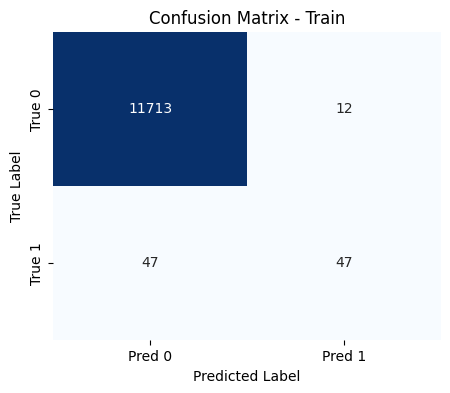

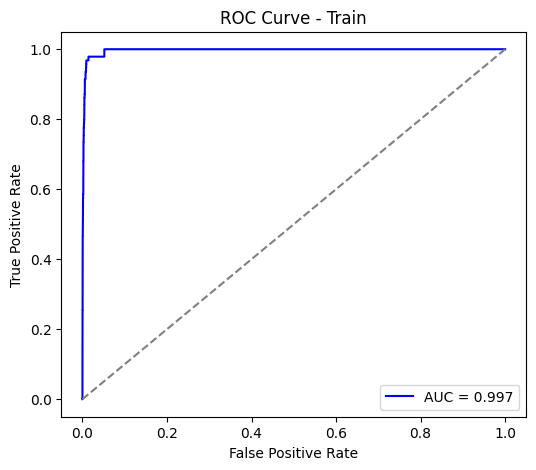

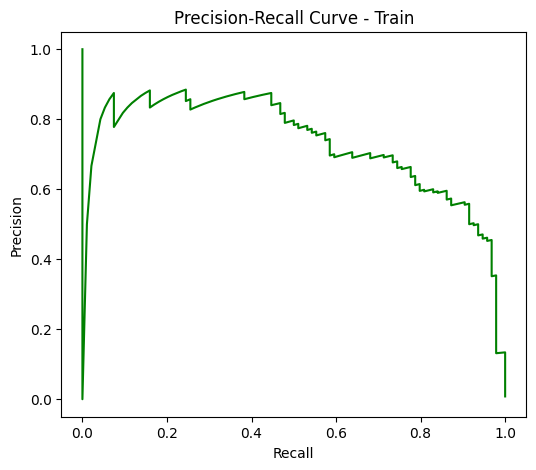

In [143]:
plot_confusion_matrix(y_train_split, y_train_pred, "Train")
plot_roc_curve(y_train_split, y_train_prob, "Train")
plot_pr_curve(y_train_split, y_train_prob, "Train")

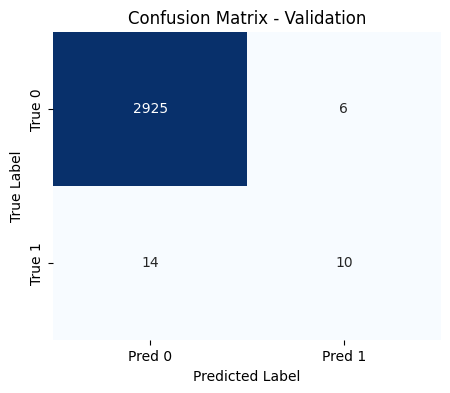

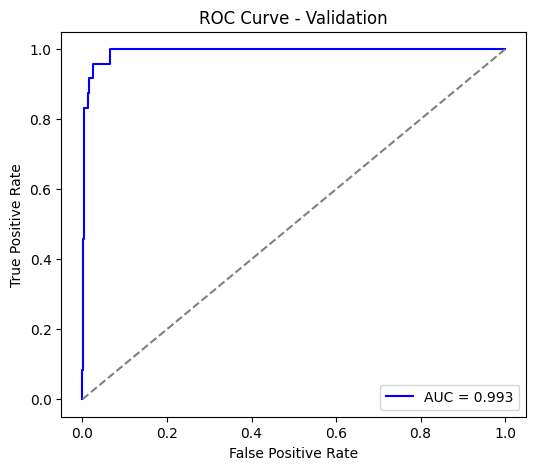

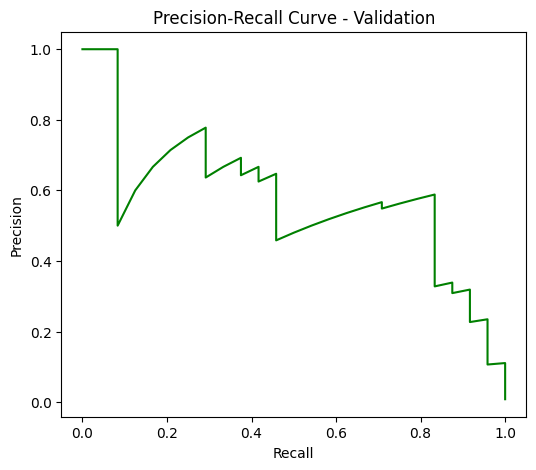

In [144]:
plot_confusion_matrix(y_valid, y_val_pred, "Validation")
plot_roc_curve(y_valid, y_val_prob, "Validation")
plot_pr_curve(y_valid, y_val_prob, "Validation")

In [145]:
# <Student to fill this section>
business_impacts_explanations = """
The confusion matrix shows that the model's overall accuracy is very high, but there is an imbalance in predictive performance between classes. The ROC curve demonstrates strong discriminatory power, with an AUC value close to 0.99, indicating high reliability in distinguishing between positive and negative classes. However, the precision-recall curve shows that while the model has high recall for the minority class, its precision remains low.

From a business perspective, this imbalance implies the following:

If the cost of false positives is high (for example, incorrectly labeling a normal customer or player as risky), the business may incur additional operational costs.

If the cost of false negatives is even higher (for example, missing truly risky or fraudulent cases), then a model that currently favors high recall is advantageous. However, improving precision while maintaining recall would significantly improve business efficiency.

Therefore, in practical applications, businesses may need to combine threshold adjustments (for example, finding the optimal F1 threshold based on the validation set) to strike a balance between reducing false positives and false negatives. A high ROC-AUC score indicates that the model has a good foundation. However, to maximize its value in the business, it needs to be combined with specific cost sensitivity analysis and strategy adjustments.
"""

In [146]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [147]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Partially Confirmed"

In [148]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [149]:
# <Student to fill this section>
experiment_results_explanations = """
The experimental results partially validated the hypothesis. The logistic regression model achieved a high ROC-AUC (approximately 0.99) on both the training and validation sets, demonstrating strong discriminatory power.

However, the experiment still encountered some issues. First, there was an imbalance between precision and recall.
Although the recall was close to 1.0, the precision was low, indicating that the model tended to classify samples as positive, but this resulted in a high number of false positives.

From a business perspective, this means the model performed well in reducing false positives and is suitable for scenarios where the cost of false positives is high. Although the impact of losing a high-performing player in NBA draft selections may be greater than the impact of gaining an average player, the additional costs of this issue need to be considered.

Next steps for improvement include:
1. Balancing precision and recall by adjusting the classification threshold (e.g., using the F1 optimality threshold);
2. Experimenting with more complex algorithms (e.g., XGBoost and LightGBM) to capture nonlinear feature interactions;
3. Implementing a feature factory that is more consistent with the algorithm and incorporating more domain features to improve predictive power.

Overall, logistic regression has demonstrated its potential as a baseline model. Subsequent feature optimization is expected to further improve model performance and enhance business value.
"""

In [150]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)